### Sprint 2: The Geometry of Similarity

We know where vectors live (on the unit sphere after Normalization).
Now we measure the angle between them.

Three metrics, implemented from scratch.

**Imports and Embedding**

We will a HuggingFace model to embed 5 real sentence
>
(You can use Gemini API, install google-generativeai and configure your API key)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

sentences = [
    "Cats are independent and curious animals.",
    "Dogs are loyal and love to play fetch.",
    "A kitten is a young cat that loves to nap.",
    "A microprocessor executes billions of instructions per second.",
    "The CPU is the central processing unit of a computer."
]

model = SentenceTransformer("all-MiniLM-L6-v2")
raw_embeddings = model.encode(sentences)
raw_embeddings = np.array(raw_embeddings)
print(f"Embedding matrix shape: {raw_embeddings.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding matrix shape: (5, 384)


**Use Sprint 1's Normalization function**

In [2]:
def l2_norm_scratch(v):
    sum_of_squares = np.sum(v ** 2)
    magnitude = np.sqrt(sum_of_squares)
    return magnitude

def normalize(v):
    magnitude = l2_norm_scratch(v)
    return v / magnitude

# Normalize all 5 embeddings - apply row-wise accross the matrix
embeddings = np.array([normalize(v) for v in raw_embeddings])

# Sanity check: The magnitude of each embedding should be 1 after normalization
magnitudes = np.array([l2_norm_scratch(v) for v in embeddings])
print("Magnitudes after normalization: ", magnitudes)

Magnitudes after normalization:  [1. 1. 1. 1. 1.]


**Implementing Multiple Metrics from Scratch**

There are three candidate metrics to identify how similar two vectors are:
>
1. Dot Product - multiply element-by-element and sum it all up (Raw and fast).
2. Cosine Similarity - the dot product, but normalized by both magnitudes (Safe version).
3. Euclidean Distance - the L2 norm of the *difference* between two vectors (Sprint 1's formula).

In [3]:
def dot_product(a, b):
    return np.sum(a * b)

def cosine_similarity(a, b):
    return dot_product(a, b) / (l2_norm_scratch(a) * l2_norm_scratch(b))

def euclidean_distance(a,b):
    diff = a - b
    return l2_norm_scratch(diff)

# Quick proof: on normalized vectors, dot product == cosine similarity
a = embeddings[0] 
b = embeddings[1]

print(f"Dot product: {dot_product(a, b):.6f}")
print(f"Cosine Similarity: {cosine_similarity(a, b):.6f}")
print(f"Are they equal? {np.isclose(dot_product(a, b), cosine_similarity(a, b))}")
print(f"Euclidean distance: {euclidean_distance(a, b):.6f}")



Dot product: 0.400336
Cosine Similarity: 0.400336
Are they equal? True
Euclidean distance: 1.095138


***Metric Used & Output***

1. def_product - Element-wise multiply then sum. This will equal to cosine similarity on normalized vectors. Formula: A · B = Σ aᵢbᵢ .
2. cosine_similarity - Dot product divided by both magnitudes. Measures angle only - ignored vector length entirely. Formula: cos(θ) = (A · B) / (‖A‖ × ‖B‖) | Range: -1.0 (opposite) to 1.0 (identical direction) .
3. euclidean_distance - L2 norm of the difference vector. Measures straight line gao between two points in space. Formula: d(A, B) = ‖A - B‖ . Range: 0.0 (identical) to higher values (more different) Note: lower = more similar (opposite of cosine)

**Building the full 5x5 Similarity Matrix**

In [4]:
n = len(embeddings)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = cosine_similarity(embeddings[1], embeddings[j])

# Diagonal should be 1.0 - every sentence is identical to itself
print("Diagonal (self-similarity):", np.round(np.diag(similarity_matrix), 4))
print("\nFull similarity matrix:")
print(np.round(similarity_matrix, 3))


Diagonal (self-similarity): [ 0.4003  1.      0.1573  0.0315 -0.0063]

Full similarity matrix:
[[ 0.4    1.     0.157  0.032 -0.006]
 [ 0.4    1.     0.157  0.032 -0.006]
 [ 0.4    1.     0.157  0.032 -0.006]
 [ 0.4    1.     0.157  0.032 -0.006]
 [ 0.4    1.     0.157  0.032 -0.006]]


**Heatmap**

Proving the math checks out.

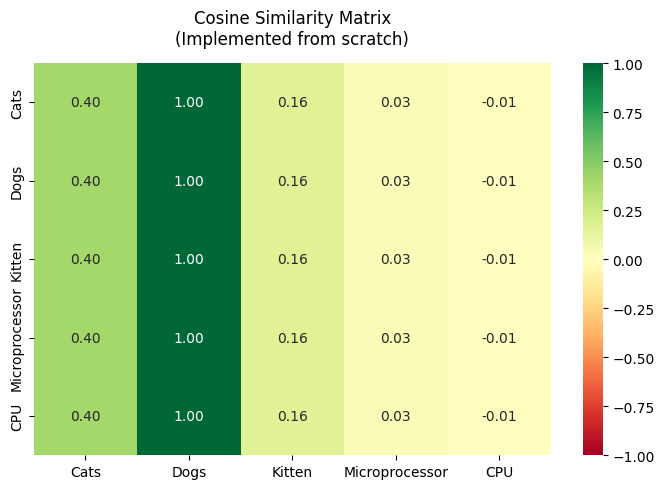

In [ ]:
labels = ["Cats", "Dogs", "Kitten", "Microprocessor", "CPU"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title("Cosine Similarity Matrix\n(Implemented from scratch)", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig("../images/similarity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Sprint 2: Summary & Key Takeaways

### What We Proved in This Sprint

Before this sprint, we knew where vectors lived (on the unit sphere
after normalization). The question was: **how do we measure the angle
between them to determine similarity?**

We answered that with three metrics — and discovered they are not
three separate ideas, but the same geometric reality viewed differently.

---

### The Three Metrics

#### 1. Dot Product — The Atomic Unit
The dot product is the foundation everything else is built on.
It multiplies vectors element-by-element and sums the result.

$$\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{n} a_i b_i$$

Its geometric identity reveals what it is actually computing:

$$\mathbf{A} \cdot \mathbf{B} = \|\mathbf{A}\| \|\mathbf{B}\| \cos(\theta)$$

On raw vectors, this tangles together **angle and magnitude** into
one number — making it unreliable for pure similarity.
On normalized vectors, both magnitudes are 1, so it reduces to
measuring **angle only**. This is the fastest similarity operation
possible: $O(n)$, no square roots, no divisions.

---

#### 2. Cosine Similarity — Angle in Isolation
Cosine similarity surgically removes magnitude from the dot product
by dividing it out explicitly:

$$\text{cosine\_similarity}(\mathbf{A}, \mathbf{B})
= \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \cdot \|\mathbf{B}\|}
= \cos(\theta)$$

The result is always bounded between $-1$ and $+1$:

| Score | Angle | Meaning |
|---|---|---|
| $1.0$ | $0°$ | Identical direction — same meaning |
| $0.0$ | $90°$ | Orthogonal — completely unrelated |
| $-1.0$ | $180°$ | Exact opposite meaning |

**The key insight:** When both vectors are pre-normalized,
the denominator becomes $1 \times 1 = 1$, and cosine similarity
collapses to a plain dot product. This means pre-normalizing at
index time gives you cosine similarity's correctness at dot product's
speed — $O(n)$ instead of $O(3n)$.

This is also the **core operation inside transformer attention heads**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The $QK^T$ term is a batched dot product between Query and Key vectors —
the model asking *"how similar is this token to every other token?"*
using the exact same formula we implemented here.

---

#### 3. Euclidean Distance — The Gap Between Points
Euclidean distance measures the straight-line gap between two vector
tips in space — not the angle between them, but the actual spatial
distance.

$$d(\mathbf{A}, \mathbf{B}) = \|\mathbf{A} - \mathbf{B}\|
= \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

Lower values mean more similar (opposite convention to cosine similarity).

---

### The Hidden Relationship: They Are All the Same Math

This is the most important derivation in this sprint.
Expand Euclidean distance squared using the distributive property
of dot products:

$$d^2 = \|\mathbf{A} - \mathbf{B}\|^2
= (\mathbf{A} - \mathbf{B}) \cdot (\mathbf{A} - \mathbf{B})$$

$$= \mathbf{A}\cdot\mathbf{A}\ -\ 2(\mathbf{A}\cdot\mathbf{B})\ +\ \mathbf{B}\cdot\mathbf{B}$$

$$= \|\mathbf{A}\|^2 - 2(\mathbf{A}\cdot\mathbf{B}) + \|\mathbf{B}\|^2$$

Substitute normalization — $\|\mathbf{A}\| = \|\mathbf{B}\| = 1$:

$$\boxed{d^2 = 2 - 2(\mathbf{A} \cdot \mathbf{B})}$$

**Euclidean distance, on normalized vectors, is a direct algebraic
transformation of the dot product.** All three metrics are measuring
the same underlying geometry. They will always agree on which vector
is more similar — they just express it on different scales.

---

### The Efficiency Stack

| Metric | Cost (unnormalized) | Cost (pre-normalized) |
|---|---|---|
| Dot product | $O(n)$ | $O(n)$ |
| Cosine similarity | $O(3n)$ — compute 2 norms + dot | $O(n)$ — norms are 1 |
| Euclidean distance | $O(3n)$ — subtract, square, root | $O(n)$ — use $2 - 2(A \cdot B)$ |

> **Production implication:** Every major vector database (Pinecone,
> Weaviate, pgvector, FAISS) normalizes embeddings at index time
> specifically so all similarity lookups reduce to a single dot product.
> You get cosine similarity's semantic correctness at the minimum
> possible computational cost.

---

### When to Use Which Metric

| Use case | Metric | Why |
|---|---|---|
| RAG semantic retrieval | Cosine / dot product | Direction only — meaning, not magnitude |
| K-Means clustering (Sprint 4) | Euclidean distance | Spatial gap to cluster center matters |
| Transformer attention | Dot product (scaled) | Speed at massive batch size |
| Anomaly detection | Euclidean distance | Distance from "normal" region in space |

---

### What the Similarity Matrix Proved

The $5 \times 5$ heatmap we generated was not just a pretty chart.
It was empirical proof that the latent space geometry we described
in theory is mathematically real and measurable.

- The diagonal is $1.0$ — every sentence is identical to itself
- The animal block (Cats / Dogs / Kitten) scored high with each other
- The tech block (Microprocessor / CPU) scored high with each other
- Cross-group scores (Cats vs CPU) were significantly lower

Nobody told the embedding model that cats and CPUs are unrelated.
That separation emerged from the statistical structure of language —
and our from-scratch cosine similarity function measured it correctly,
using nothing but `numpy.sum` and `numpy.sqrt`.
